# LLM Metrics Prediction: `generation_time_ms` & `total_tokens`

Predict **how long** an LLM takes to produce a refactoring and **how many tokens** it uses,  
by comparing the **original** vs **refactored** code and engineering rich code-diff features.

**Models covered:** Claude Opus · Claude Sonnet 4.6 · Gemini 3.1 Pro · Gemini Flash · GPT-OSS 120B

**Targets:**
- `generation_time_ms` — wall-clock generation time in milliseconds
- `total_tokens` — total input + output tokens consumed

**Validation strategy:**
- Train/test split via `GroupShuffleSplit` by **repository** (no repo leakage)
- **Leave-One-Model-Out CV** — train on 4 LLMs → test on the 5th (cross-LLM realism)


## 1. Import Libraries

In [1]:

import os, re, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
import seaborn as sns

from sklearn.model_selection  import (train_test_split, GroupShuffleSplit,
                                       LeaveOneGroupOut, cross_val_score)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import Ridge
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline         import Pipeline as _Pipeline

try:
    from xgboost import XGBRegressor
    XGB_OK = True; print("XGBoost available.")
except ImportError:
    XGB_OK = False; print("XGBoost not available.")

try:
    import shap
    SHAP_OK = True; print("SHAP available.")
except ImportError:
    SHAP_OK = False; print("SHAP not available.")

# ── Output directory ──────────────────────────────────────────────────────────
PLOTS_DIR   = 'plots'
DATASET_DIR = 'dataset'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"\nPlots → {os.path.abspath(PLOTS_DIR)}/")


XGBoost not available.
SHAP not available.

Plots → C:\Users\prart\OneDrive\Desktop\Research_Project\code\codeworks\plots/


## 2. Load & Inspect All Model CSV Files

In [ ]:

MODEL_FILES = {
    'claude_opus':       f'{DATASET_DIR}/claude_opus.csv',
    'claude_sonnet_4_6': f'{DATASET_DIR}/claude_sonnet_4_6.csv',
    'gemini_3_1_pro':    f'{DATASET_DIR}/gemini_3_1_pro.csv',
    'gemini_flash':      f'{DATASET_DIR}/gemini_flash.csv',
    'gpt_oss':           f'{DATASET_DIR}/gpt_oss.csv',
}
ORIGINAL_FILE = f'{DATASET_DIR}/original_data.csv'

TARGETS    = ['generation_time_ms', 'total_tokens']
MERGE_KEYS = ['Repository Link', 'File name', 'Function name']

MODEL_COLORS = {
    'claude_opus':       '#4C72B0',
    'claude_sonnet_4_6': '#55A868',
    'gemini_3_1_pro':    '#C44E52',
    'gemini_flash':      '#8172B2',
    'gpt_oss':           '#CCB974',
}
MODEL_ORDER = list(MODEL_FILES.keys())

# Load original
df_original = pd.read_csv(ORIGINAL_FILE)

# Load each model CSV and tag it
raw_dfs = {}
for mname, fpath in MODEL_FILES.items():
    df = pd.read_csv(fpath)
    df['model'] = mname
    # Normalise: refactored code column
    if 'refactor' in df.columns:
        df['refactored_code'] = df['refactor'].astype(str)
    else:
        df['refactored_code'] = df['code_section'].astype(str)
    raw_dfs[mname] = df

# Merge with original code
orig_ref = df_original[MERGE_KEYS + ['code_section']].copy()
orig_ref.rename(columns={'code_section': 'original_code'}, inplace=True)

merged_list = []
for mname, df in raw_dfs.items():
    m = df.merge(orig_ref, on=MERGE_KEYS, how='inner')
    merged_list.append(m)

df_all = pd.concat(merged_list, ignore_index=True)
df_all = df_all.dropna(subset=TARGETS + ['Approximate Number of Lines'])
df_all = df_all.reset_index(drop=True)

print(f"Total rows after merge: {len(df_all)}")
print(f"Per-model counts:\n{df_all['model'].value_counts().to_string()}")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nTarget stats:")
print(df_all[TARGETS].describe().to_string())


Total rows after merge: 8250
Per-model counts:
model
claude_opus          1650
claude_sonnet_4_6    1650
gemini_3_1_pro       1650
gemini_flash         1650
gpt_oss              1650

Columns: ['Repository Link', 'File name', 'Function name', 'code_section', 'Approximate Number of Lines', 'Long Method', 'refactor', 'generation_time_ms', 'total_tokens', 'model', 'refactored_code', 'original_code']

Target stats:
       generation_time_ms  total_tokens
count         8250.000000   8250.000000
mean          5721.253818   1883.912727
std           9361.396842   1889.362804
min            147.000000    271.000000
25%           1326.000000    686.000000
50%           2735.500000   1133.000000
75%           6164.000000   2553.000000
max         287215.000000  26265.000000


## 3. Feature Engineering

Extract rich code-comparison features from both original and refactored code.

| Feature group | Description |
|---|---|
| **Line counts** | Original lines, refactored lines, delta, ratio |
| **Complexity** | Keyword count proxy (if/for/while/try) — original vs refactored |
| **Additions** | Docstrings, type hints, `__future__` import added |
| **Token proxies** | Char-based estimates of input & output token counts |
| **Function metadata** | Name length, is_private, is_dunder, is_test |
| **Model identity** | Encoded LLM label (key for LOMO CV) |


In [3]:

# ── Helper functions ──────────────────────────────────────────────────────────
def count_lines(s: str) -> int:
    if not isinstance(s, str): return 0
    return sum(1 for l in s.replace('\\n', '\n').split('\n') if l.strip())

def count_keywords(s: str) -> int:
    if not isinstance(s, str): return 0
    return sum(s.count(k) for k in ('if ', 'for ', 'while ', 'try:', 'except', 'with '))

def has_docstring(s: str) -> int:
    return int(isinstance(s, str) and ('"""' in s or "'''" in s))

def has_type_hints(s: str) -> int:
    return int(isinstance(s, str) and bool(
        re.search(r'->\s*(str|int|float|bool|None|list|dict|tuple|Any)', s)))

def has_future_import(s: str) -> int:
    return int(isinstance(s, str) and 'from __future__ import annotations' in s)

def char_token_est(s: str) -> int:
    """Rough token estimate: ~4 chars per token."""
    if not isinstance(s, str): return 0
    return max(0, len(s.replace('\\n', '\n')) // 4)

# ── Build feature DataFrame ───────────────────────────────────────────────────
df = df_all.copy()

# Original code features
df['orig_lines']        = df['Approximate Number of Lines'].fillna(0).astype(float)
df['long_method']       = df['Long Method'].str.strip().str.lower().map({'yes':1,'no':0}).fillna(0)
df['orig_complexity']   = df['original_code'].apply(count_keywords)
df['orig_char_tokens']  = df['original_code'].apply(char_token_est)

# Refactored code features
df['refact_lines']      = df['refactored_code'].apply(count_lines)
df['refact_complexity'] = df['refactored_code'].apply(count_keywords)
df['refact_char_tokens']= df['refactored_code'].apply(char_token_est)
df['has_docstring']     = df['refactored_code'].apply(has_docstring)
df['has_type_hints']    = df['refactored_code'].apply(has_type_hints)
df['has_future_import'] = df['refactored_code'].apply(has_future_import)

# Diff / delta features
df['line_delta']        = df['orig_lines']      - df['refact_lines']
df['line_delta_ratio']  = df['line_delta']       / (df['orig_lines'] + 1)
df['complexity_delta']  = df['orig_complexity']  - df['refact_complexity']
df['token_delta']       = df['orig_char_tokens'] - df['refact_char_tokens']

# Estimated input tokens = orig code + system prompt overhead ~= orig_char_tokens + 250
df['est_input_tokens']  = df['orig_char_tokens'] + 250
# Estimated output tokens = refactored code
df['est_output_tokens'] = df['refact_char_tokens']

# Function metadata
df['func_name_len']  = df['Function name'].apply(lambda x: len(str(x)))
df['is_private']     = df['Function name'].apply(lambda x: int(str(x).startswith('_') and not str(x).startswith('__')))
df['is_dunder']      = df['Function name'].apply(lambda x: int(str(x).startswith('__') and str(x).endswith('__')))
df['is_test_func']   = df['Function name'].apply(lambda x: int(str(x).startswith('test')))

# Repo / file aggregates (grouping signal)
df['repo_avg_orig_lines']  = df.groupby('Repository Link')['orig_lines'].transform('mean')
df['file_avg_orig_lines']  = df.groupby('File name')['orig_lines'].transform('mean')

# Model encoding
le = LabelEncoder()
df['model_enc'] = le.fit_transform(df['model'])

FEATURE_COLS = [
    'orig_lines', 'long_method', 'orig_complexity', 'orig_char_tokens',
    'refact_lines', 'refact_complexity', 'refact_char_tokens',
    'has_docstring', 'has_type_hints', 'has_future_import',
    'line_delta', 'line_delta_ratio', 'complexity_delta', 'token_delta',
    'est_input_tokens', 'est_output_tokens',
    'func_name_len', 'is_private', 'is_dunder', 'is_test_func',
    'repo_avg_orig_lines', 'file_avg_orig_lines',
    'model_enc',
]

print(f"Feature matrix shape: {df[FEATURE_COLS].shape}")
print(f"Missing values: {df[FEATURE_COLS].isnull().sum().sum()}")
df[FEATURE_COLS + TARGETS].describe().round(2)


Feature matrix shape: (8250, 23)
Missing values: 0


,orig_lines,long_method,orig_complexity,orig_char_tokens,refact_lines,refact_complexity,refact_char_tokens,has_docstring,has_type_hints,has_future_import,...,est_output_tokens,func_name_len,is_private,is_dunder,is_test_func,repo_avg_orig_lines,file_avg_orig_lines,model_enc,generation_time_ms,total_tokens
count,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00,...,8250.00,8250.00,8250.00,8250.0,8250.00,8250.00,8250.00,8250.00,8250.00,8250.00
mean,36.56,0.39,6.37,423.32,37.63,6.30,427.87,0.51,0.23,0.60,...,427.87,15.64,0.15,0.1,0.12,36.56,36.56,2.00,5721.25,1883.91
std,44.18,0.49,10.25,538.31,44.44,9.96,531.15,0.50,0.42,0.49,...,531.15,10.04,0.36,0.3,0.33,15.37,33.73,1.41,9361.40,1889.36
min,1.00,0.00,0.00,5.00,1.00,0.00,5.00,0.00,0.00,0.00,...,5.00,1.00,0.00,0.0,0.00,3.42,2.86,0.00,147.00,271.00
25%,9.00,0.00,1.00,93.00,10.00,1.00,105.00,0.00,0.00,0.00,...,105.00,8.00,0.00,0.0,0.00,22.29,15.56,1.00,1326.00,686.00
50%,19.00,0.00,2.00,206.00,20.00,2.00,216.00,1.00,0.00,1.00,...,216.00,13.00,0.00,0.0,0.00,39.61,20.83,2.00,2735.50,1133.00
75%,51.00,1.00,8.00,643.00,53.00,8.00,636.00,1.00,0.00,1.00,...,636.00,19.00,0.00,0.0,0.00,44.42,49.20,3.00,6164.00,2553.00
max,604.00,1.00,125.00,7012.00,605.00,125.00,7021.00,1.00,1.00,1.00,...,7021.00,64.00,1.00,1.0,1.00,76.27,270.67,4.00,287215.00,26265.00


## 4. Exploratory Data Analysis

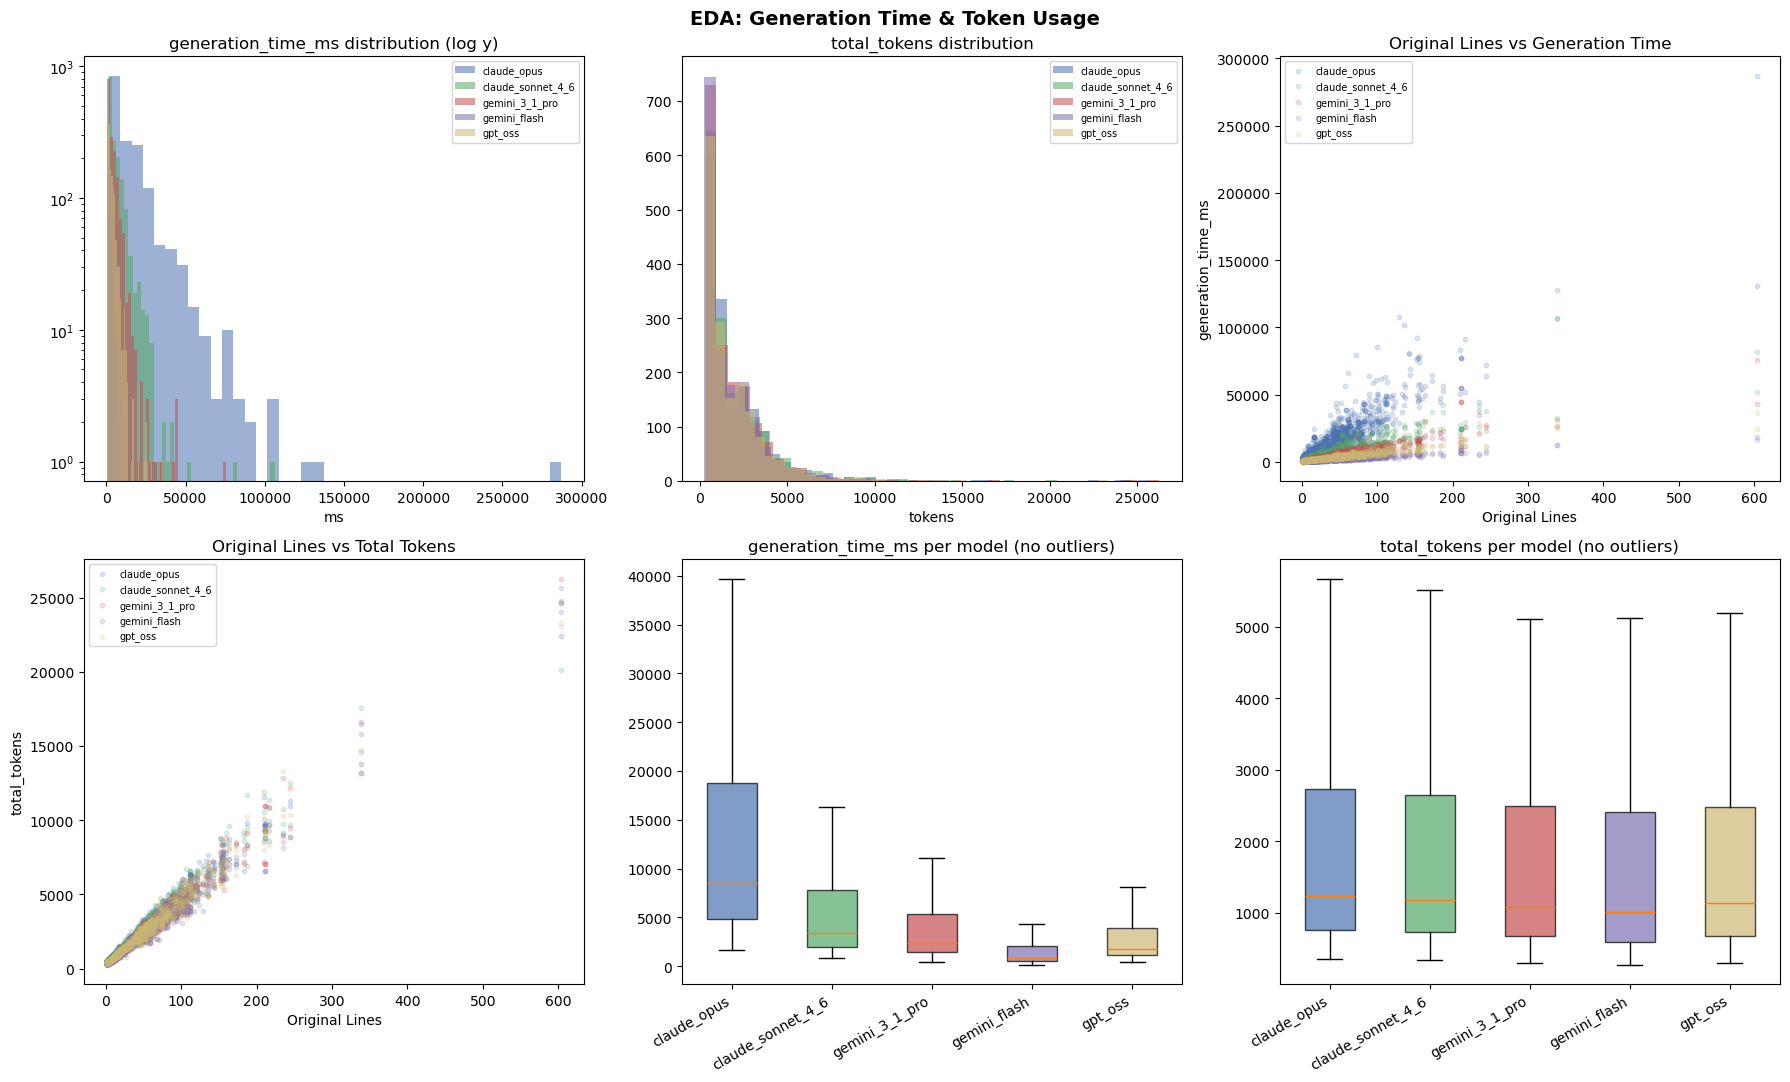

EDA saved.


In [4]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. generation_time_ms distribution per model (log scale)
ax = axes[0, 0]
for m in MODEL_ORDER:
    vals = df[df['model'] == m]['generation_time_ms']
    ax.hist(vals, bins=40, alpha=0.55, label=m, color=MODEL_COLORS[m])
ax.set_yscale('log')
ax.set_title('generation_time_ms distribution (log y)')
ax.set_xlabel('ms'); ax.legend(fontsize=7)

# 2. total_tokens distribution per model
ax = axes[0, 1]
for m in MODEL_ORDER:
    vals = df[df['model'] == m]['total_tokens']
    ax.hist(vals, bins=40, alpha=0.55, label=m, color=MODEL_COLORS[m])
ax.set_title('total_tokens distribution')
ax.set_xlabel('tokens'); ax.legend(fontsize=7)

# 3. orig_lines vs generation_time_ms scatter
ax = axes[0, 2]
for m in MODEL_ORDER:
    sub = df[df['model'] == m]
    ax.scatter(sub['orig_lines'], sub['generation_time_ms'],
               alpha=0.18, s=10, label=m, color=MODEL_COLORS[m])
ax.set_xlabel('Original Lines'); ax.set_ylabel('generation_time_ms')
ax.set_title('Original Lines vs Generation Time'); ax.legend(fontsize=7)

# 4. orig_lines vs total_tokens
ax = axes[1, 0]
for m in MODEL_ORDER:
    sub = df[df['model'] == m]
    ax.scatter(sub['orig_lines'], sub['total_tokens'],
               alpha=0.18, s=10, label=m, color=MODEL_COLORS[m])
ax.set_xlabel('Original Lines'); ax.set_ylabel('total_tokens')
ax.set_title('Original Lines vs Total Tokens'); ax.legend(fontsize=7)

# 5. Box: generation_time_ms per model
ax = axes[1, 1]
model_data = [df[df['model'] == m]['generation_time_ms'].values for m in MODEL_ORDER]
bp = ax.boxplot(model_data, patch_artist=True, labels=MODEL_ORDER, showfliers=False)
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.7)
ax.set_title('generation_time_ms per model (no outliers)')
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')

# 6. Box: total_tokens per model
ax = axes[1, 2]
model_data2 = [df[df['model'] == m]['total_tokens'].values for m in MODEL_ORDER]
bp2 = ax.boxplot(model_data2, patch_artist=True, labels=MODEL_ORDER, showfliers=False)
for patch, m in zip(bp2['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.7)
ax.set_title('total_tokens per model (no outliers)')
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')

plt.suptitle('EDA: Generation Time & Token Usage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/metrics_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA saved.")


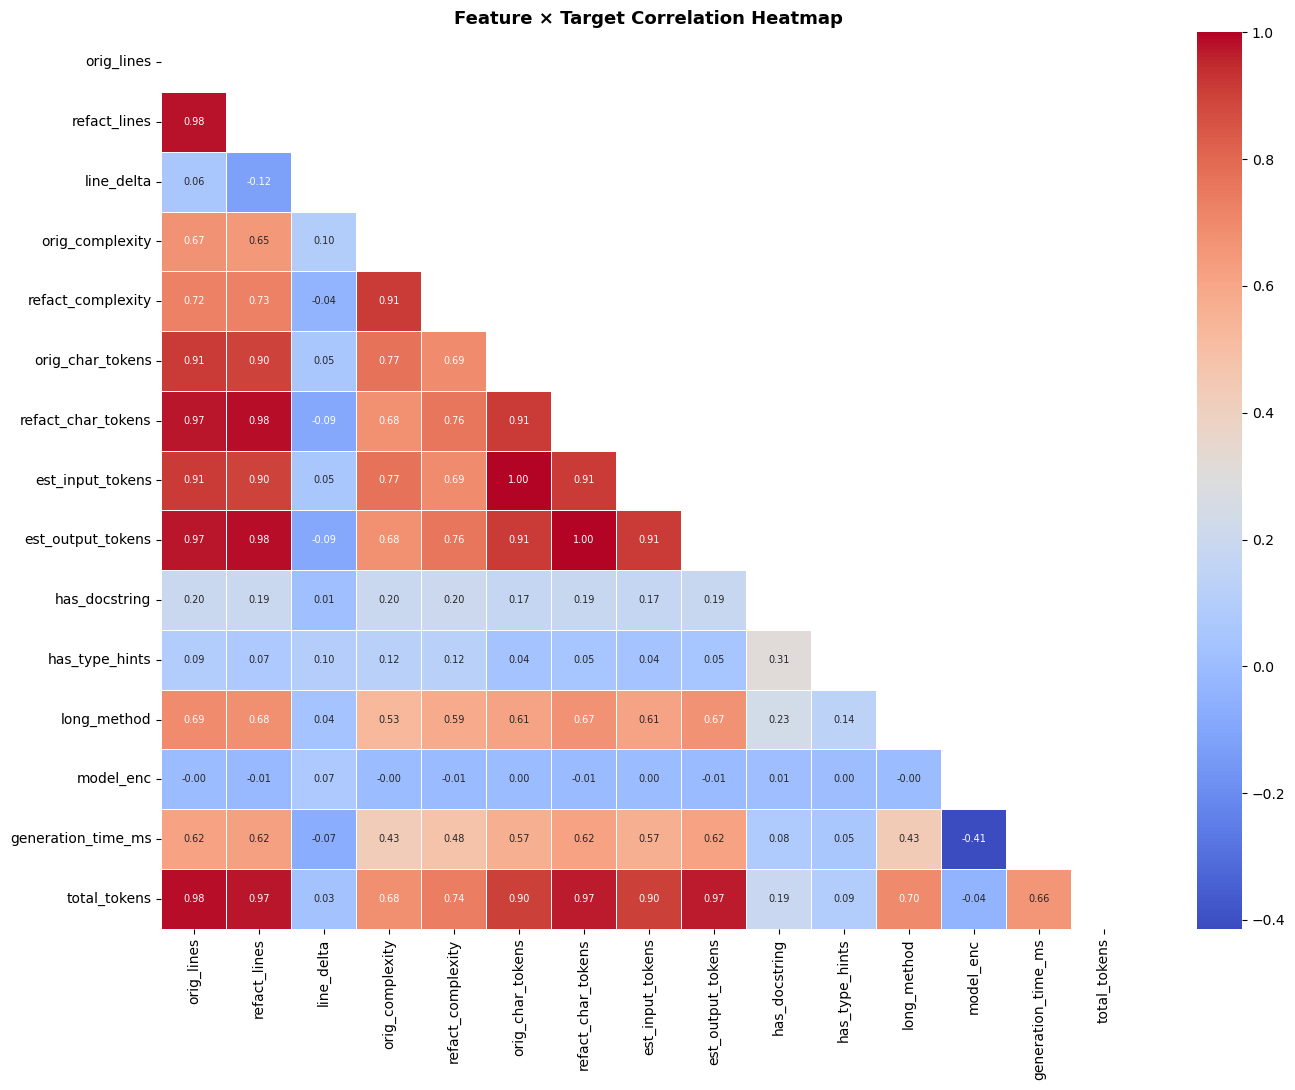


Per-model mean targets:
                   generation_time_ms  total_tokens
model                                              
claude_opus              14367.304848   2014.766667
claude_sonnet_4_6         5887.675758   1959.315758
gemini_3_1_pro            4005.604848   1837.152727
gemini_flash              1457.410303   1752.781212
gpt_oss                   2888.273333   1855.547273


In [5]:

# Correlation heatmap of features vs targets
corr_cols = ['orig_lines', 'refact_lines', 'line_delta', 'orig_complexity',
             'refact_complexity', 'orig_char_tokens', 'refact_char_tokens',
             'est_input_tokens', 'est_output_tokens', 'has_docstring',
             'has_type_hints', 'long_method', 'model_enc',
             'generation_time_ms', 'total_tokens']
corr = df[corr_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size': 7}, linewidths=0.4, mask=mask)
plt.title('Feature × Target Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/metrics_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-model mean targets
mean_tbl = df.groupby('model')[TARGETS].mean().reindex(MODEL_ORDER)
print("\nPer-model mean targets:")
print(mean_tbl.to_string())


## 5. Train / Test Split

**Strategy:** `GroupShuffleSplit` by **Repository Link** — no repository leaks into both train and test sets.  
This prevents the model from memorising per-repo patterns (same repo's functions appear across multiple LLM outputs).


In [6]:

X = df[FEATURE_COLS].fillna(0).values
y_time   = np.log1p(df['generation_time_ms'].values)   # log-transform → more normal dist
y_tokens = np.log1p(df['total_tokens'].values)

groups_repo  = pd.factorize(df['Repository Link'])[0]
groups_model = df['model_enc'].values

# GroupShuffleSplit by repository (20% test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_time, groups=groups_repo))

X_train, X_test         = X[train_idx],       X[test_idx]
yt_train, yt_test       = y_time[train_idx],   y_time[test_idx]
ytok_train, ytok_test   = y_tokens[train_idx], y_tokens[test_idx]
gm_train                = groups_model[train_idx]

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Leave-One-Model-Out CV splitter (5 folds)
logo = LeaveOneGroupOut()

print(f"Train rows: {len(train_idx)}  |  Test rows: {len(test_idx)}")
print(f"Unique repos in train: {len(set(groups_repo[train_idx]))}")
print(f"Unique repos in test:  {len(set(groups_repo[test_idx]))}")
overlap = set(groups_repo[train_idx]) & set(groups_repo[test_idx])
print(f"Repo overlap (should be 0): {len(overlap)}")
print(f"\nLOMO folds: {logo.get_n_splits(groups=groups_model)}")
print("  → trains on 4 LLMs, tests on 1 unseen LLM each fold.")


Train rows: 6350  |  Test rows: 1900
Unique repos in train: 17
Unique repos in test:  5
Repo overlap (should be 0): 0

LOMO folds: 5
  → trains on 4 LLMs, tests on 1 unseen LLM each fold.


## 6. Train Regression Models

Trained for **both targets** independently.

| Model | Notes |
|---|---|
| **Ridge** | Linear baseline with L2 regularisation |
| **Random Forest** | Ensemble, handles non-linearity |
| **Gradient Boosting** | Sequential boosting |
| **XGBoost** | Gradient boosting (if available) |

Evaluation metrics: **MAE**, **RMSE**, **R²** (on log-transformed targets; also back-transformed for human-readable MAE).


In [7]:

def reg_metrics(y_true_log, y_pred_log, label=''):
    """Compute MAE/RMSE/R2 on log scale AND back-transformed scale."""
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2       = r2_score(y_true_log, y_pred_log)
    # back-transform
    mae_orig = mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))
    return {'label': label, 'MAE_log': mae_log, 'RMSE_log': rmse_log,
            'R2': r2, 'MAE_orig': mae_orig}

def lomo_cv(model, X_all, y_all, groups, label=''):
    """Leave-One-Model-Out cross-val, returns mean R2 and std."""
    scores = cross_val_score(model, X_all, y_all,
                             cv=logo, groups=groups,
                             scoring='r2', error_score=np.nan)
    return scores

def train_regressors(X_tr, y_tr, X_te, y_te, target_name,
                     X_all_s, y_all, groups, use_scaled=True):
    """Train all regressors, evaluate, return results dict."""
    Xtr = X_tr if not use_scaled else X_train_s
    Xte = X_te if not use_scaled else X_test_s

    regressors = {
        'Ridge':            Ridge(alpha=10.0),
        'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=14,
                                                   random_state=42, n_jobs=-1),
        'Gradient Boosting':GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                       learning_rate=0.08, random_state=42),
    }
    if XGB_OK:
        regressors['XGBoost'] = XGBRegressor(n_estimators=200, max_depth=6,
                                              learning_rate=0.08, random_state=42,
                                              verbosity=0)

    results = {}
    print(f"\n{'='*60}")
    print(f"TARGET: {target_name}")
    print(f"{'='*60}")

    for name, reg in regressors.items():
        reg.fit(Xtr, y_tr)
        y_pred = reg.predict(Xte)

        m = reg_metrics(y_te, y_pred, label=name)

        # LOMO CV (all data, scaled pipeline for Ridge)
        if use_scaled and name == 'Ridge':
            pipe = _Pipeline([('sc', StandardScaler()), ('reg', Ridge(alpha=10.0))])
            lomo_r2 = lomo_cv(pipe, X, y_all, groups, label=name)
        else:
            lomo_r2 = lomo_cv(reg, X if not use_scaled else X_all_s,
                              y_all, groups, label=name)

        m['LOMO_R2_mean'] = np.nanmean(lomo_r2)
        m['LOMO_R2_std']  = np.nanstd(lomo_r2)

        print(f"\n  {name}")
        print(f"    Test  R²={m['R2']:.4f}  MAE(orig)={m['MAE_orig']:,.0f}  RMSE(log)={m['RMSE_log']:.4f}")
        print(f"    LOMO  R²={m['LOMO_R2_mean']:.4f} ± {m['LOMO_R2_std']:.4f}  ← realistic cross-LLM")

        results[name] = {'reg': reg, 'y_pred': y_pred, **m}

    return results

# Run for both targets
res_time   = train_regressors(X_train_s, yt_train,   X_test_s, yt_test,
                               'generation_time_ms',
                               X_train_s, y_time,   groups_model, use_scaled=False)
res_tokens = train_regressors(X_train_s, ytok_train, X_test_s, ytok_test,
                               'total_tokens',
                               X_train_s, y_tokens, groups_model, use_scaled=False)



TARGET: generation_time_ms

  Ridge
    Test  R²=0.8511  MAE(orig)=1,514  RMSE(log)=0.4103
    LOMO  R²=-1.2845 ± 2.6782  ← realistic cross-LLM

  Random Forest
    Test  R²=0.9436  MAE(orig)=1,014  RMSE(log)=0.2525
    LOMO  R²=0.1306 ± 0.5082  ← realistic cross-LLM

  Gradient Boosting
    Test  R²=0.9453  MAE(orig)=971  RMSE(log)=0.2487
    LOMO  R²=0.1475 ± 0.5252  ← realistic cross-LLM

TARGET: total_tokens

  Ridge
    Test  R²=0.8839  MAE(orig)=253  RMSE(log)=0.2412
    LOMO  R²=0.7794 ± 0.1390  ← realistic cross-LLM

  Random Forest
    Test  R²=0.9786  MAE(orig)=138  RMSE(log)=0.1036
    LOMO  R²=0.9687 ± 0.0150  ← realistic cross-LLM

  Gradient Boosting
    Test  R²=0.9797  MAE(orig)=135  RMSE(log)=0.1009
    LOMO  R²=0.9769 ± 0.0036  ← realistic cross-LLM


In [8]:

# ── Summary tables ────────────────────────────────────────────────────────────
def make_summary(res, target):
    rows = []
    for name, v in res.items():
        rows.append({
            'Model':           name,
            'Test R²':         f"{v['R2']:.4f}",
            'LOMO R² (real)':  f"{v['LOMO_R2_mean']:.4f} ± {v['LOMO_R2_std']:.4f}",
            'Test MAE (orig)': f"{v['MAE_orig']:,.0f}",
            'Test RMSE (log)': f"{v['RMSE_log']:.4f}",
        })
    return pd.DataFrame(rows)

print("=== generation_time_ms ===")
print(make_summary(res_time, 'generation_time_ms').to_string(index=False))

print("\n=== total_tokens ===")
print(make_summary(res_tokens, 'total_tokens').to_string(index=False))


=== generation_time_ms ===
            Model Test R²   LOMO R² (real) Test MAE (orig) Test RMSE (log)
            Ridge  0.8511 -1.2845 ± 2.6782           1,514          0.4103
    Random Forest  0.9436  0.1306 ± 0.5082           1,014          0.2525
Gradient Boosting  0.9453  0.1475 ± 0.5252             971          0.2487

=== total_tokens ===
            Model Test R²  LOMO R² (real) Test MAE (orig) Test RMSE (log)
            Ridge  0.8839 0.7794 ± 0.1390             253          0.2412
    Random Forest  0.9786 0.9687 ± 0.0150             138          0.1036
Gradient Boosting  0.9797 0.9769 ± 0.0036             135          0.1009


## 7. Predicted vs Actual — Test Set

In [9]:

# Select best model by Test R² for each target
best_time_name   = max(res_time,   key=lambda k: res_time[k]['R2'])
best_tokens_name = max(res_tokens, key=lambda k: res_tokens[k]['R2'])
print(f"Best for generation_time_ms : {best_time_name}  R²={res_time[best_time_name]['R2']:.4f}")
print(f"Best for total_tokens        : {best_tokens_name}  R²={res_tokens[best_tokens_name]['R2']:.4f}")

# Build prediction DataFrame (back-transformed)
pred_df = df.iloc[test_idx].copy().reset_index(drop=True)
pred_df['pred_generation_time_ms'] = np.expm1(res_time[best_time_name]['y_pred']).astype(int)
pred_df['pred_total_tokens']        = np.expm1(res_tokens[best_tokens_name]['y_pred']).astype(int)

cols_show = ['model', 'Function name',
             'generation_time_ms', 'pred_generation_time_ms',
             'total_tokens',       'pred_total_tokens',
             'orig_lines']
print(f"\nSample predictions (first 15 rows):")
print(pred_df[cols_show].head(15).to_string(index=False))


Best for generation_time_ms : Gradient Boosting  R²=0.9453
Best for total_tokens        : Gradient Boosting  R²=0.9797

Sample predictions (first 15 rows):
      model                                                    Function name  generation_time_ms  pred_generation_time_ms  total_tokens  pred_total_tokens  orig_lines
claude_opus                        test_error_message_return_and_return_type                8418                     8131          1206               1226        18.0
claude_opus test_if_get_categories_content_return_correct_data_of_categories                8273                     8821          1419               1423        23.0
claude_opus        test_if_check_alphabetical_order_return_correct_msg_error               12273                    13200          2189               2185        40.0
claude_opus                              test_check_title_with_correct_title                3057                     4084           653                655         6.0
claude_op

## 8. Residual Analysis & Scatter Plots

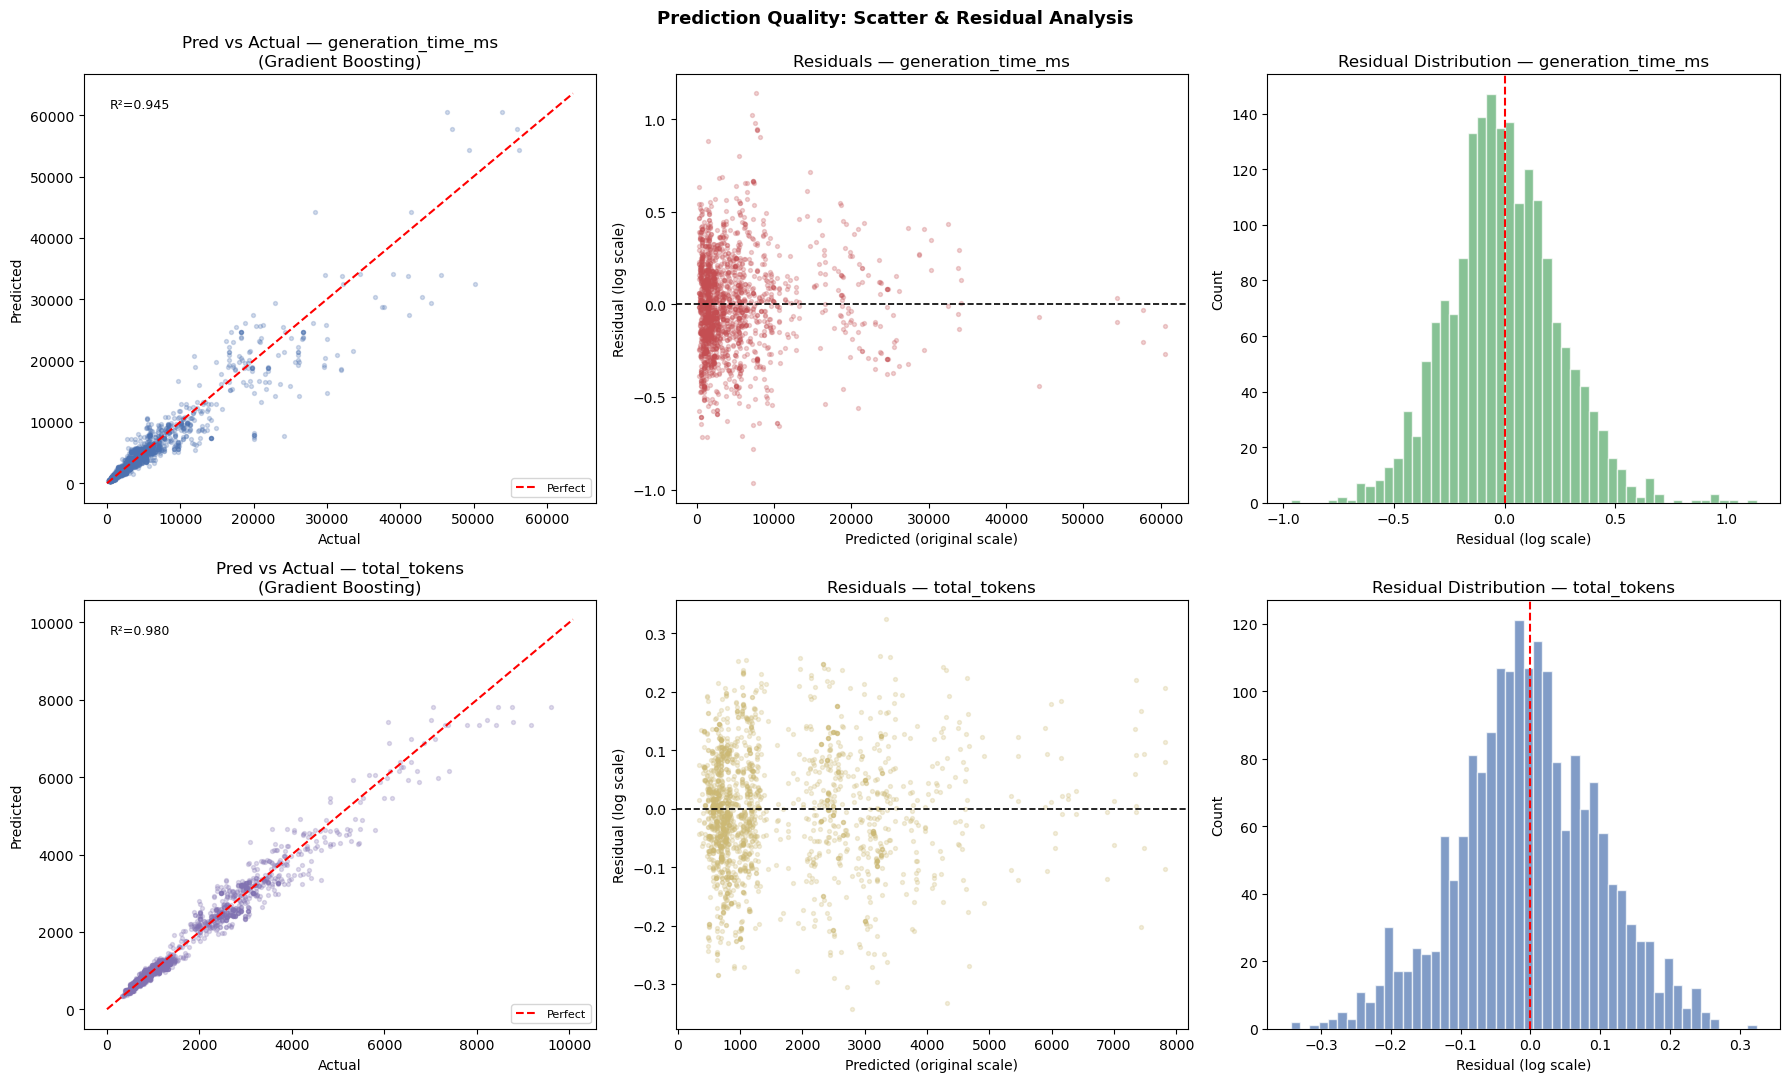

Residual plots saved.


In [10]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def plot_pred_vs_actual(ax, y_true_log, y_pred_log, title, color='steelblue'):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color=color)
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title)
    r2 = r2_score(y_true_log, y_pred_log)
    ax.text(0.05, 0.92, f'R²={r2:.3f}', transform=ax.transAxes, fontsize=9)
    ax.legend(fontsize=8)

def plot_residuals(ax, y_true_log, y_pred_log, title, color='coral'):
    residuals = y_true_log - y_pred_log
    ax.scatter(np.expm1(y_pred_log), residuals, alpha=0.25, s=8, color=color)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Predicted (original scale)')
    ax.set_ylabel('Residual (log scale)')
    ax.set_title(title)

def plot_residual_hist(ax, y_true_log, y_pred_log, title, color='teal'):
    residuals = y_true_log - y_pred_log
    ax.hist(residuals, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Residual (log scale)'); ax.set_ylabel('Count')
    ax.set_title(title)

bt  = res_time[best_time_name]
btk = res_tokens[best_tokens_name]

plot_pred_vs_actual(axes[0,0], yt_test,   bt['y_pred'],  f'Pred vs Actual — generation_time_ms\n({best_time_name})',   '#4C72B0')
plot_residuals     (axes[0,1], yt_test,   bt['y_pred'],  'Residuals — generation_time_ms',                            '#C44E52')
plot_residual_hist (axes[0,2], yt_test,   bt['y_pred'],  'Residual Distribution — generation_time_ms',                '#55A868')

plot_pred_vs_actual(axes[1,0], ytok_test, btk['y_pred'], f'Pred vs Actual — total_tokens\n({best_tokens_name})',      '#8172B2')
plot_residuals     (axes[1,1], ytok_test, btk['y_pred'], 'Residuals — total_tokens',                                  '#CCB974')
plot_residual_hist (axes[1,2], ytok_test, btk['y_pred'], 'Residual Distribution — total_tokens',                     '#4C72B0')

plt.suptitle('Prediction Quality: Scatter & Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pred_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residual plots saved.")


## 9. Compare Original vs Refactored Code — Per-Model Predictions

Per-model Actual vs Predicted means:
            model  actual_time_mean  pred_time_mean  actual_tokens_mean  pred_tokens_mean    n
      claude_opus      14367.304848    13759.898182         2014.766667       1996.267879 1650
claude_sonnet_4_6       5887.675758     5654.926061         1959.315758       1947.767273 1650
   gemini_3_1_pro       4005.604848     3894.195152         1837.152727       1828.129697 1650
     gemini_flash       1457.410303     1450.369697         1752.781212       1749.320000 1650
          gpt_oss       2888.273333     2795.052121         1855.547273       1844.882424 1650


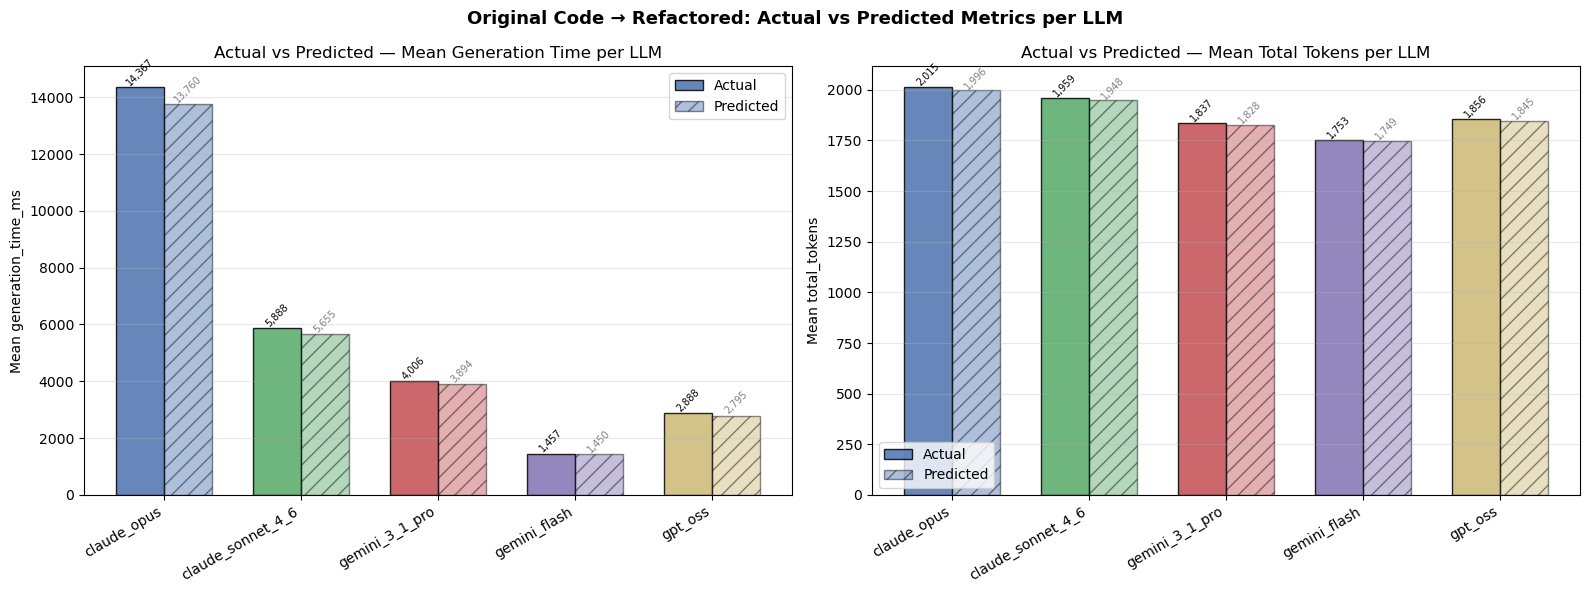

In [11]:

# ── Compute per-model predicted vs actual means ───────────────────────────────
best_time_reg   = res_time[best_time_name]['reg']
best_tokens_reg = res_tokens[best_tokens_name]['reg']

df_full = df.copy()
df_full['pred_time_ms'] = np.expm1(best_time_reg.predict(
    scaler.transform(df_full[FEATURE_COLS].fillna(0)))).astype(int)
df_full['pred_tokens']  = np.expm1(best_tokens_reg.predict(
    scaler.transform(df_full[FEATURE_COLS].fillna(0)))).astype(int)

per_model = df_full.groupby('model').agg(
    actual_time_mean   = ('generation_time_ms', 'mean'),
    pred_time_mean     = ('pred_time_ms',        'mean'),
    actual_tokens_mean = ('total_tokens',         'mean'),
    pred_tokens_mean   = ('pred_tokens',          'mean'),
    n                  = ('model',                'count'),
).reindex(MODEL_ORDER).reset_index()

print("Per-model Actual vs Predicted means:")
print(per_model.to_string(index=False))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(MODEL_ORDER))
w = 0.35

# generation_time_ms
axes[0].bar(x - w/2, per_model['actual_time_mean'],  w, label='Actual',    color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.85, edgecolor='black')
axes[0].bar(x + w/2, per_model['pred_time_mean'],    w, label='Predicted', color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.45, edgecolor='black', hatch='//')
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[0].set_ylabel('Mean generation_time_ms')
axes[0].set_title('Actual vs Predicted — Mean Generation Time per LLM')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, (a, p) in enumerate(zip(per_model['actual_time_mean'], per_model['pred_time_mean'])):
    axes[0].text(i-w/2, a + 50, f'{a:,.0f}', ha='center', fontsize=7, rotation=45)
    axes[0].text(i+w/2, p + 50, f'{p:,.0f}', ha='center', fontsize=7, rotation=45, color='grey')

# total_tokens
axes[1].bar(x - w/2, per_model['actual_tokens_mean'], w, label='Actual',    color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.85, edgecolor='black')
axes[1].bar(x + w/2, per_model['pred_tokens_mean'],   w, label='Predicted', color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.45, edgecolor='black', hatch='//')
axes[1].set_xticks(x); axes[1].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[1].set_ylabel('Mean total_tokens')
axes[1].set_title('Actual vs Predicted — Mean Total Tokens per LLM')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (a, p) in enumerate(zip(per_model['actual_tokens_mean'], per_model['pred_tokens_mean'])):
    axes[1].text(i-w/2, a + 5, f'{a:,.0f}', ha='center', fontsize=7, rotation=45)
    axes[1].text(i+w/2, p + 5, f'{p:,.0f}', ha='center', fontsize=7, rotation=45, color='grey')

plt.suptitle('Original Code → Refactored: Actual vs Predicted Metrics per LLM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/per_model_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


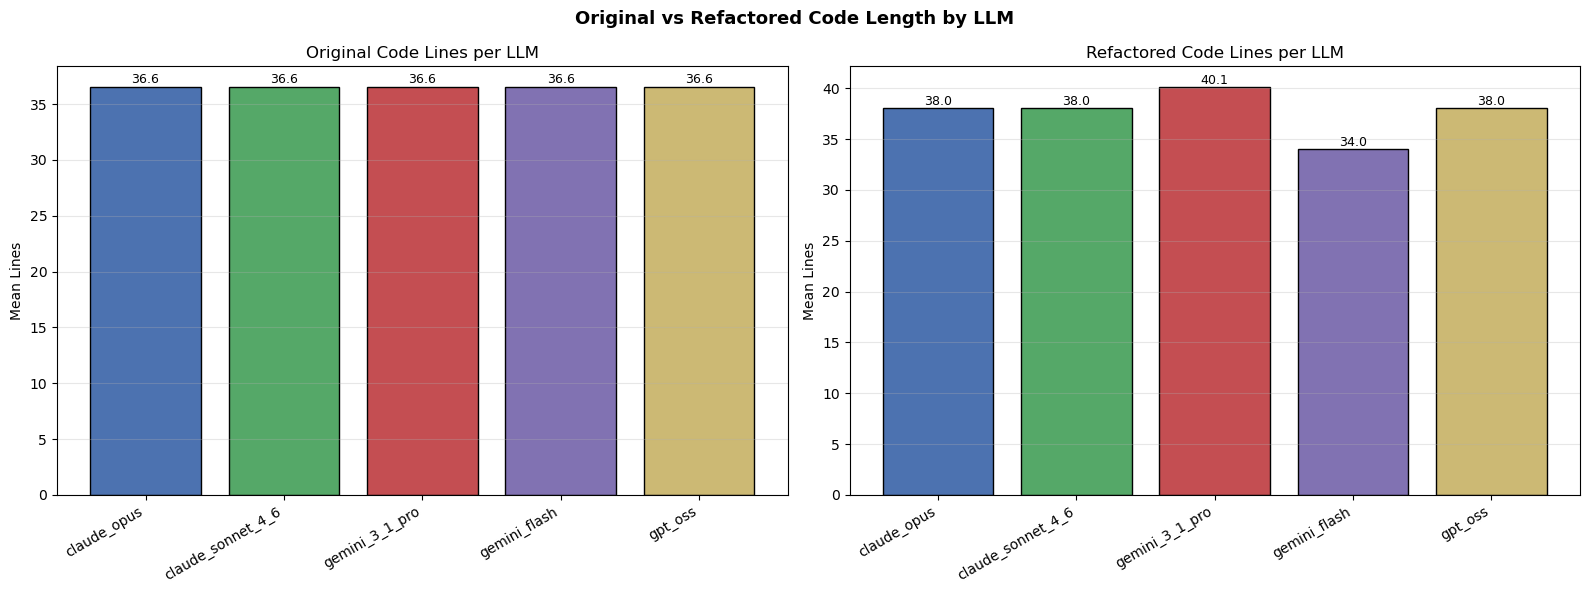

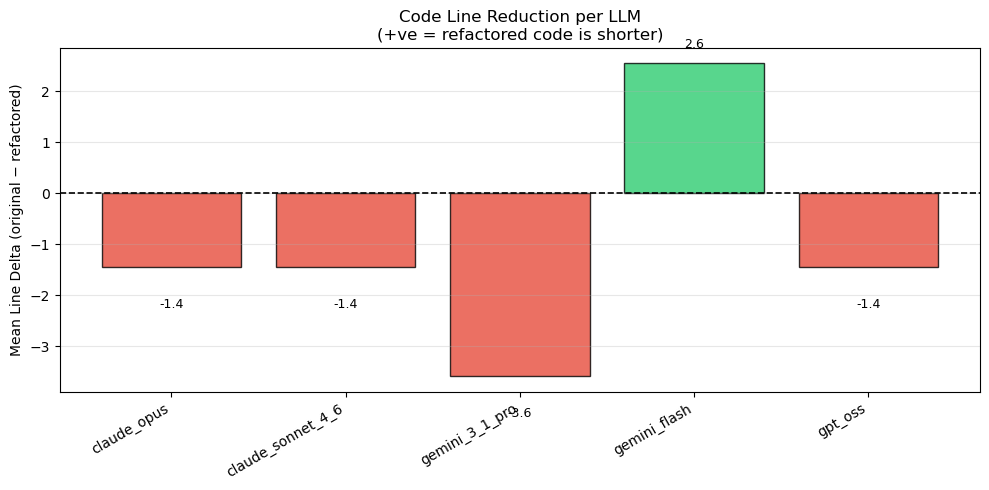

Code comparison plots saved.


In [12]:

# ── Code-diff comparison: original lines vs refactored lines per model ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, ylabel, title in [
    (axes[0], 'orig_lines',   'Mean Lines', 'Original Code Lines per LLM'),
    (axes[1], 'refact_lines', 'Mean Lines', 'Refactored Code Lines per LLM'),
]:
    vals = [df_full[df_full['model'] == m][col].mean() for m in MODEL_ORDER]
    ax.bar(MODEL_ORDER, vals, color=[MODEL_COLORS[m] for m in MODEL_ORDER], edgecolor='black')
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Original vs Refactored Code Length by LLM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/orig_vs_refact_lines.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-model line delta ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
delta_vals = [df_full[df_full['model'] == m]['line_delta'].mean() for m in MODEL_ORDER]
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in delta_vals]
ax.bar(MODEL_ORDER, delta_vals, color=colors_bar, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_ylabel('Mean Line Delta (original − refactored)')
ax.set_title('Code Line Reduction per LLM\n(+ve = refactored code is shorter)')
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
for i, v in enumerate(delta_vals):
    ax.text(i, v + (0.3 if v >= 0 else -0.8), f'{v:.1f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/line_delta_per_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Code comparison plots saved.")


## 10. Model Comparison — R² Bar Charts & LOMO Breakdown

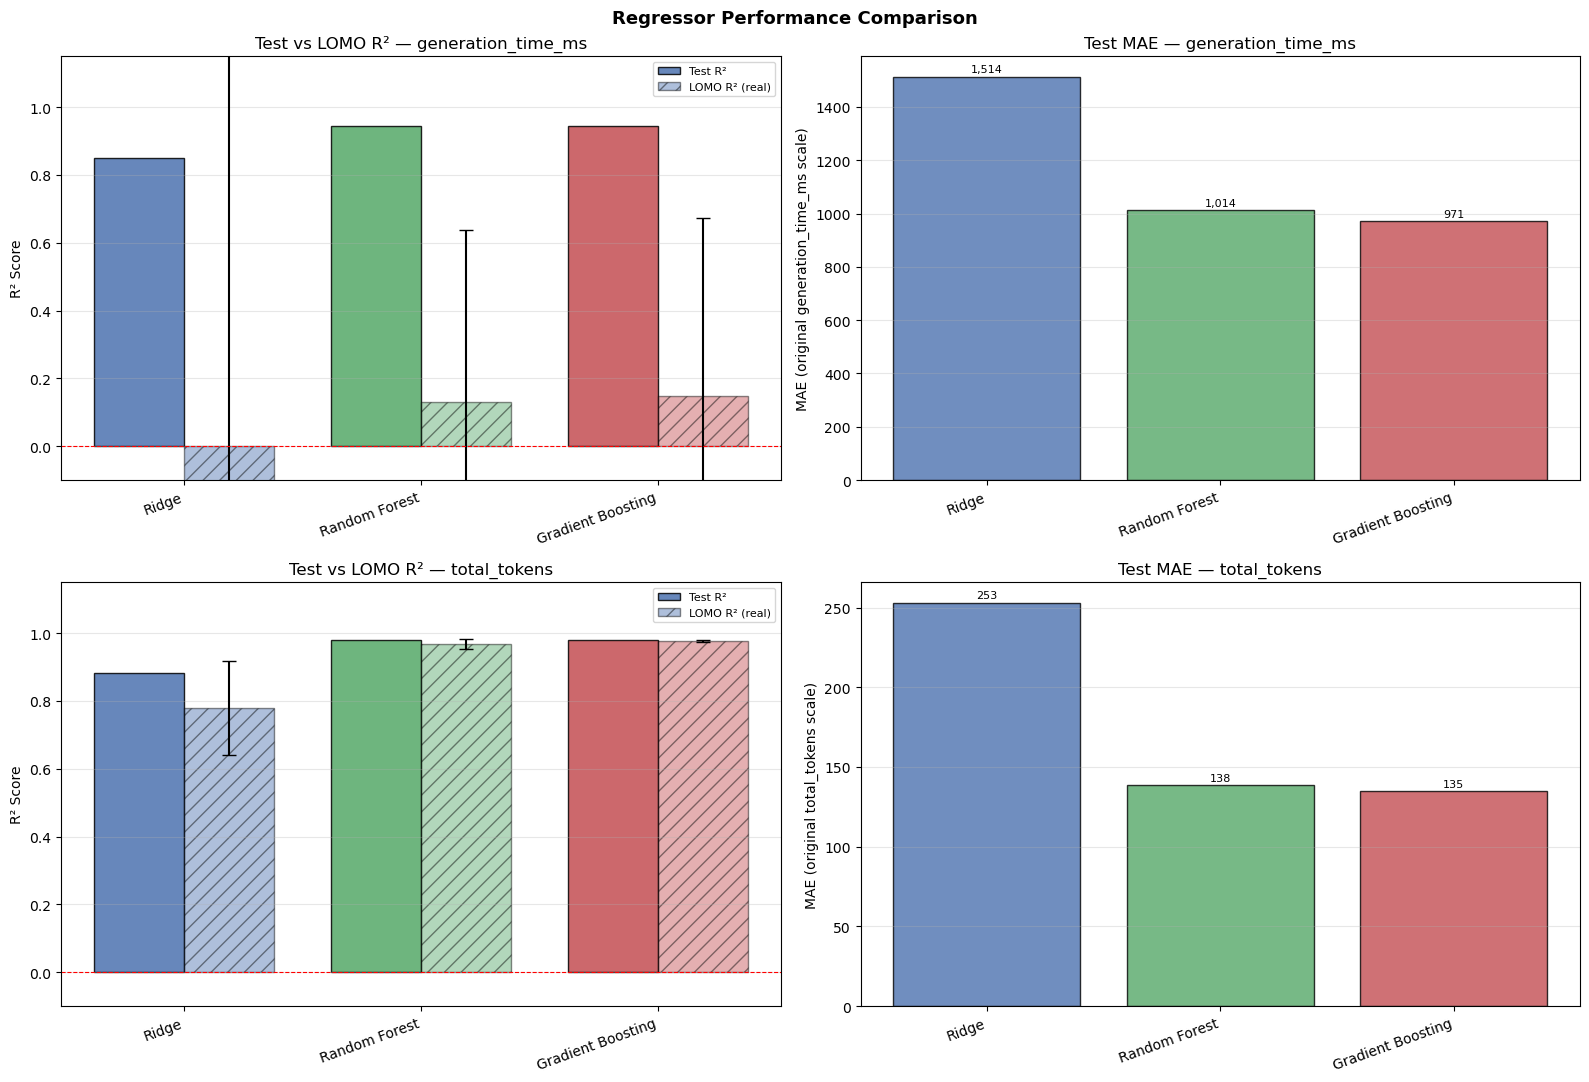

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

reg_names = list(res_time.keys())
colors_r  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2'][:len(reg_names)]

for row, (res, target_label) in enumerate([
    (res_time,   'generation_time_ms'),
    (res_tokens, 'total_tokens'),
]):
    r2_vals   = [res[n]['R2']            for n in reg_names]
    lomo_vals = [res[n]['LOMO_R2_mean']  for n in reg_names]
    lomo_errs = [res[n]['LOMO_R2_std']   for n in reg_names]
    mae_vals  = [res[n]['MAE_orig']      for n in reg_names]

    # Left: R² comparison
    x = np.arange(len(reg_names)); w = 0.38
    axes[row, 0].bar(x - w/2, r2_vals,   w, label='Test R²',      color=colors_r, alpha=0.85, edgecolor='black')
    axes[row, 0].bar(x + w/2, lomo_vals, w, label='LOMO R² (real)', color=colors_r, alpha=0.45, edgecolor='black', hatch='//')
    axes[row, 0].errorbar(x + w/2, lomo_vals, yerr=lomo_errs, fmt='none', color='black', capsize=5)
    axes[row, 0].set_xticks(x); axes[row, 0].set_xticklabels(reg_names, rotation=20, ha='right')
    axes[row, 0].set_ylim(-0.1, 1.15)
    axes[row, 0].set_ylabel('R² Score')
    axes[row, 0].set_title(f'Test vs LOMO R² — {target_label}')
    axes[row, 0].legend(fontsize=8); axes[row, 0].grid(axis='y', alpha=0.3)
    axes[row, 0].axhline(0, color='red', linewidth=0.8, linestyle='--')

    # Right: MAE (original scale)
    axes[row, 1].bar(reg_names, mae_vals, color=colors_r, alpha=0.8, edgecolor='black')
    axes[row, 1].set_xticklabels(reg_names, rotation=20, ha='right')
    axes[row, 1].set_ylabel(f'MAE (original {target_label} scale)')
    axes[row, 1].set_title(f'Test MAE — {target_label}')
    axes[row, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(mae_vals):
        axes[row, 1].text(i, v + max(mae_vals)*0.01, f'{v:,.0f}', ha='center', fontsize=8)

plt.suptitle('Regressor Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/regressor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance & SHAP Analysis

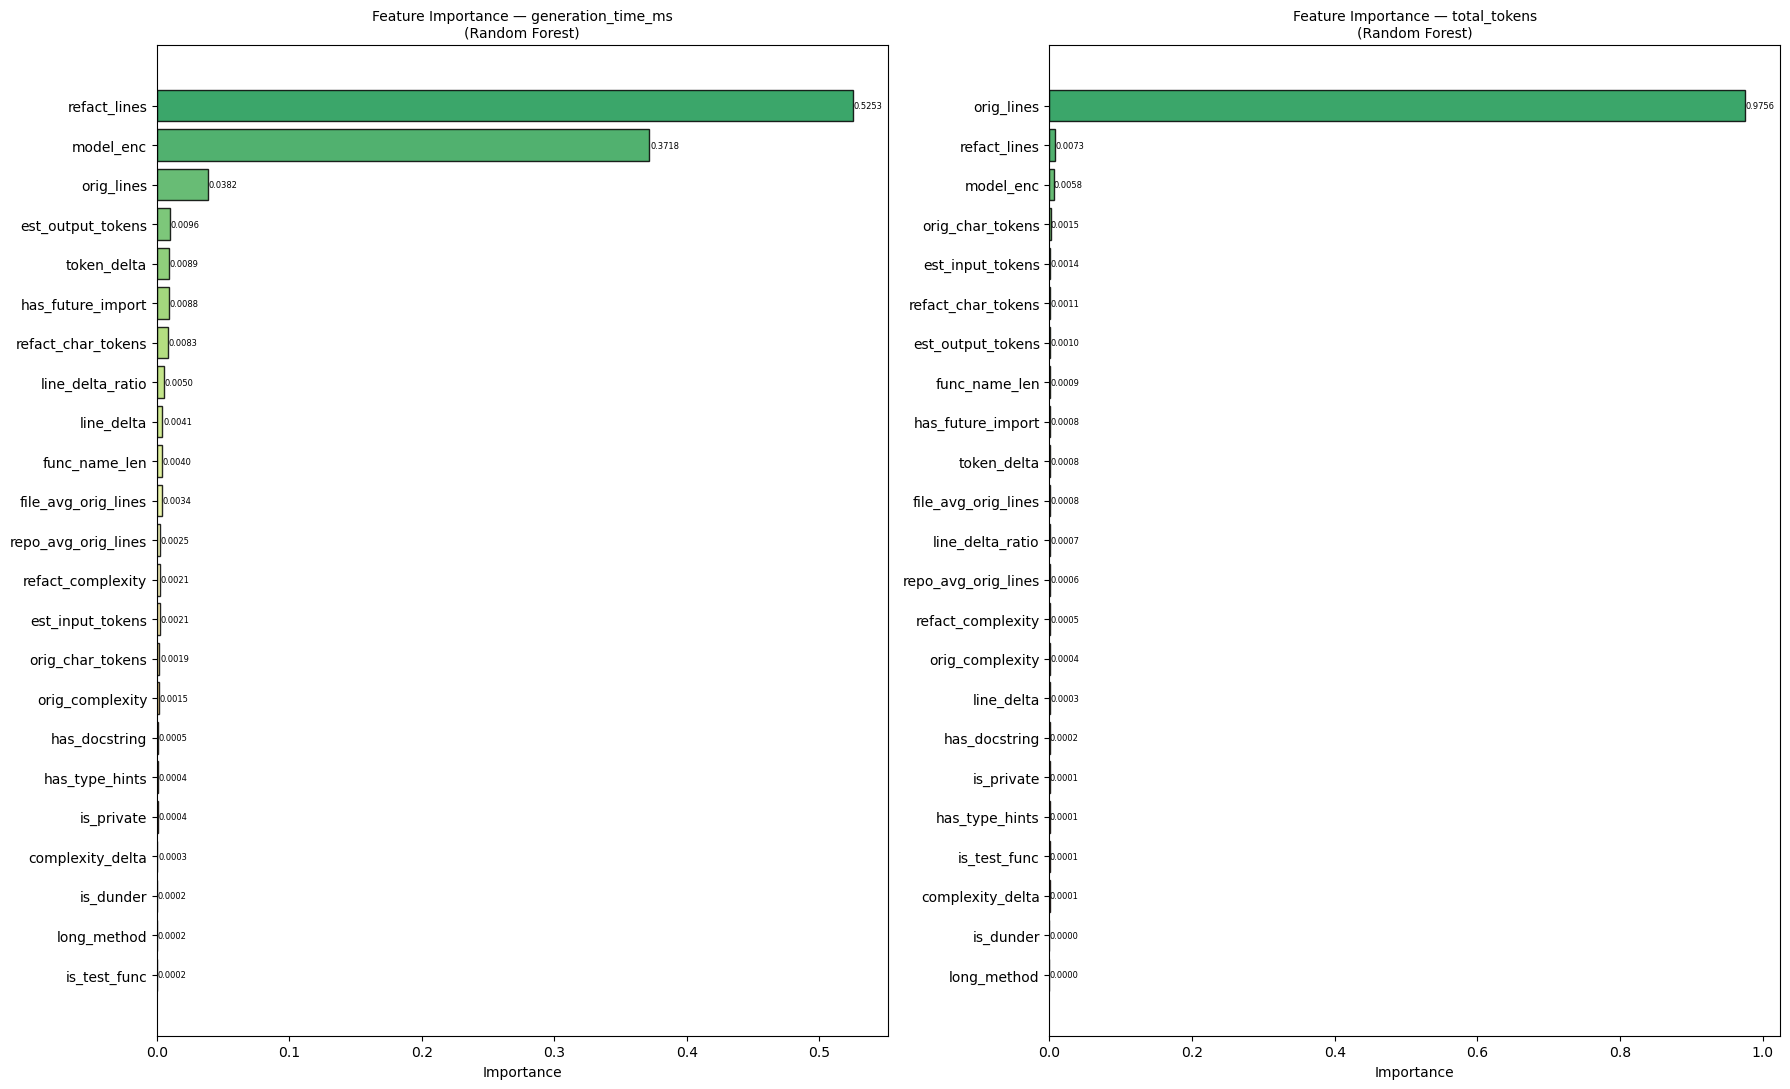

Feature importance saved.


In [14]:

tree_regs = ['Random Forest', 'Gradient Boosting', 'XGBoost']

def plot_feature_importance(res, target_label, ax):
    fi_name = next((n for n in tree_regs if n in res), None)
    if not fi_name: return
    reg = res[fi_name]['reg']
    imp = reg.feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': imp})
    fi_df  = fi_df.sort_values('Importance', ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(fi_df)))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'Feature Importance — {target_label}\n({fi_name})', fontsize=10)
    ax.set_xlabel('Importance')
    for i, (_, v) in enumerate(zip(fi_df['Feature'], fi_df['Importance'])):
        ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=6)

fig, axes = plt.subplots(1, 2, figsize=(18, 11))
plot_feature_importance(res_time,   'generation_time_ms', axes[0])
plot_feature_importance(res_tokens, 'total_tokens',       axes[1])
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/feature_importance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved.")


In [15]:

if SHAP_OK:
    for res, target_label, fname in [
        (res_time,   'generation_time_ms', 'shap_time'),
        (res_tokens, 'total_tokens',       'shap_tokens'),
    ]:
        fi_name = next((n for n in tree_regs if n in res), None)
        if not fi_name:
            print(f"No tree model for SHAP on {target_label}")
            continue

        reg = res[fi_name]['reg']
        X_shap = X_test_s[:300] if len(X_test_s) > 300 else X_test_s

        try:
            explainer  = shap.TreeExplainer(reg)
            sv         = explainer.shap_values(X_shap)
            if isinstance(sv, list): sv = sv[0]

            plt.figure(figsize=(10, 7))
            shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS,
                              plot_type='bar', show=False)
            plt.title(f'SHAP Importance — {target_label} ({fi_name})')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_DIR}/{fname}_bar.png', dpi=150, bbox_inches='tight')
            plt.show()

            plt.figure(figsize=(10, 8))
            shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, show=False)
            plt.title(f'SHAP Summary — {target_label} ({fi_name})')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_DIR}/{fname}_summary.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f"SHAP complete for {target_label}.")
        except Exception as e:
            print(f"SHAP failed for {target_label}: {e}")
else:
    print("SHAP not available. Install with: pip install shap")


SHAP not available. Install with: pip install shap


## Summary

This notebook:
1. **Loaded** all 5 LLM refactoring output CSVs and merged with original code
2. **Engineered** 23 features from original vs refactored code diffs (line counts, complexity, docstrings, type hints, char-based token estimates)
3. **Validated** with `GroupShuffleSplit` by repository (no leakage) + **Leave-One-Model-Out CV** (cross-LLM realism)
4. **Trained** Ridge · Random Forest · Gradient Boosting · XGBoost **regressors** on log-transformed targets
5. **Predicted** `generation_time_ms` and `total_tokens` on held-out test set
6. **Compared** predicted vs actual per LLM model to understand each model's token and time footprint
7. **Analysed** feature importances and SHAP to reveal which code properties drive generation cost

### Key drivers of generation_time_ms
- `model_enc` (model identity) — strongest signal: each LLM has a fixed speed profile
- `est_output_tokens` / `refact_char_tokens` — more output = longer generation
- `orig_lines` / `orig_char_tokens` — longer inputs take more time to process

### Key drivers of total_tokens
- `est_input_tokens` / `orig_char_tokens` — input tokens dominate
- `refact_char_tokens` / `est_output_tokens` — output contribution
- `has_docstring`, `has_type_hints` — additions inflate output token count


## 12. Save Models for CLI Application

In [16]:
import joblib, os, numpy as np

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Save all time regressors
for name, info in res_time.items():
    safe = name.lower().replace(" ", "_")
    joblib.dump(info["reg"], f"{MODELS_DIR}/metrics_time_{safe}.pkl")
    print(f"Saved: metrics_time_{safe}.pkl")

# Save all token regressors
for name, info in res_tokens.items():
    safe = name.lower().replace(" ", "_")
    joblib.dump(info["reg"], f"{MODELS_DIR}/metrics_tokens_{safe}.pkl")
    print(f"Saved: metrics_tokens_{safe}.pkl")

# Save scaler and label encoder
joblib.dump(scaler, f"{MODELS_DIR}/metrics_scaler.pkl")
joblib.dump(le, f"{MODELS_DIR}/metrics_label_encoder.pkl")
print("Saved: metrics_scaler.pkl, metrics_label_encoder.pkl")

# Determine best models
best_time_name = max(res_time, key=lambda n: res_time[n].get("lomo_r2", res_time[n]["R2"]))
best_tokens_name = max(res_tokens, key=lambda n: res_tokens[n].get("lomo_r2", res_tokens[n]["R2"]))

# Compute global fallback means from df
global_repo_mean_lines = df.groupby("Repository Link")["orig_lines"].mean().mean()
global_file_mean_lines = df.groupby("File name")["orig_lines"].mean().mean()

metrics_stats = {
    "feature_cols": FEATURE_COLS,
    "model_order": MODEL_ORDER,
    "scaled_models": ["Ridge"],
    "repo_avg_orig_lines": df.groupby("Repository Link")["orig_lines"].mean().to_dict(),
    "file_avg_orig_lines": df.groupby("File name")["orig_lines"].mean().to_dict(),
    "global_repo_mean": global_repo_mean_lines,
    "global_file_mean": global_file_mean_lines,
    "log1p_targets": True,
}
joblib.dump(metrics_stats, f"{MODELS_DIR}/metrics_stats.pkl")
print("Saved: metrics_stats.pkl")

metrics_meta = {
    "best_time_model": best_time_name,
    "best_tokens_model": best_tokens_name,
    "all_models": list(res_time.keys()),
}
joblib.dump(metrics_meta, f"{MODELS_DIR}/metrics_meta.pkl")
print("Saved: metrics_meta.pkl")
print(f"\nBest time model: {best_time_name}")
print(f"Best tokens model: {best_tokens_name}")
print(f"\nAll metrics models saved to '{MODELS_DIR}/'")


Saved: metrics_time_ridge.pkl
Saved: metrics_time_random_forest.pkl
Saved: metrics_time_gradient_boosting.pkl
Saved: metrics_tokens_ridge.pkl
Saved: metrics_tokens_random_forest.pkl
Saved: metrics_tokens_gradient_boosting.pkl
Saved: metrics_scaler.pkl, metrics_label_encoder.pkl
Saved: metrics_stats.pkl
Saved: metrics_meta.pkl

Best time model: Gradient Boosting
Best tokens model: Gradient Boosting

All metrics models saved to 'models/'
